# RNN, LSTM, and GRU for Text Generation
## AIAT 122 – Deep Learning

## Learning objectives
- Build a character-level LSTM for next-character prediction.
- Train on a short text and generate a sample sequence.

**Where is this used in real life?** Autocomplete, simple chatbots, and creative writing tools often use RNN/LSTM/GRU. **We use an LSTM for text generation** instead of a plain feedforward net because **order matters** in text; the LSTM processes one character at a time and keeps a hidden state so it can learn sequences.

**Prerequisites:** Basic TensorFlow/Keras. If TensorFlow import fails, see DOCS/COLAB_SETUP.md.

## Short theory
- **Character-level generation:** Model predicts the next character given previous characters.
- **LSTM** has gates (forget, input, output) that help it remember long-range dependencies better than a simple RNN.
- **Training:** Input = sequence of chars, target = next char; we use categorical cross-entropy.
- **Generation:** Feed a seed string, sample next char, append, repeat.

**📌 Covers slide(s):** Optional — do after core notebooks 01–05 (no specific slide).


## Inputs & Outputs
**Inputs:** TensorFlow/Keras, a short training text (included in the notebook).  
**Dataset:** Built-in — short text included in notebook (character-level LSTM; no external download).  
**Outputs:** Trained LSTM, training loss curve, and a short generated character sequence. Run time: under ~5 min (few epochs, small text).


In [1]:
import numpy as np
try:
    import tensorflow as tf
    from tensorflow import keras
    print("TensorFlow version:", tf.__version__)
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    raise
print("✅ Imports OK.")

TensorFlow version: 2.13.0
✅ Imports OK.


### Step 1: Prepare text and character mapping

In [2]:
# Small text for quick training (we use LSTM because order of characters matters)
text = "the quick brown fox jumps over the lazy dog. " * 50
chars = sorted(set(text))
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for c, i in char_to_idx.items()}
vocab_size = len(chars)
seq_len = 20
print(f"Text length: {len(text)}, unique chars: {vocab_size}, seq_len: {seq_len}")

Text length: 2250, unique chars: 28, seq_len: 20


### Step 2: Build sequences and LSTM model, train (10 epochs)

In [3]:
X_seq, y_seq = [], []
for i in range(len(text) - seq_len):
    X_seq.append([char_to_idx[c] for c in text[i:i+seq_len]])
    y_seq.append(char_to_idx[text[i+seq_len]])
X = np.array(X_seq, dtype=np.int32)
y = keras.utils.to_categorical(y_seq, num_classes=vocab_size)

model = keras.Sequential([
    keras.layers.Embedding(vocab_size, 32, input_length=seq_len),
    keras.layers.LSTM(64),
    keras.layers.Dense(vocab_size, activation="softmax"),
])
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
history = model.fit(X, y, epochs=10, batch_size=64, verbose=1)
print("After this cell you should see: loss going down. More epochs = better generation.")

Epoch 1/10


 1/35 [..............................] - ETA: 13s - loss: 3.3331 - accuracy: 0.0156

12/35 [=========>....................] - ETA: 0s - loss: 3.3138 - accuracy: 0.1927 

24/35 [===================>..........] - ETA: 0s - loss: 3.2579 - accuracy: 0.1960

35/35 [==============================] - 1s 4ms/step - loss: 3.2103 - accuracy: 0.1942


...

 1/35 [..............................] - ETA: 0s - loss: 0.5051 - accuracy: 1.0000

13/35 [==========>...................] - ETA: 0s - loss: 0.5092 - accuracy: 1.0000

25/35 [====================>.........] - ETA: 0s - loss: 0.4807 - accuracy: 1.0000

35/35 [==============================] - 0s 4ms/step - loss: 0.4609 - accuracy: 1.0000


After this cell you should see: loss going down. More epochs = better generation.


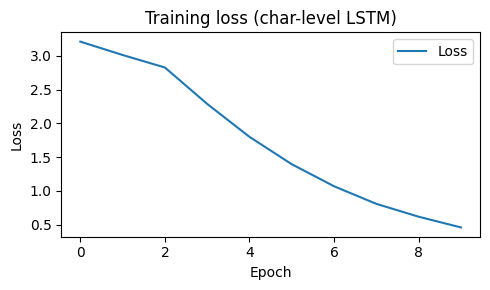

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 3))
plt.plot(history.history["loss"], label="Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss (char-level LSTM)")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# Generate 40 chars. Use a seed of length seq_len from the training text so the model
# sees a context it learned (better output). Short seeds are left-padded to seq_len.
seed = text[:seq_len]  # e.g. "the quick brown fox " — or try "the " for a shorter seed
generated = seed
pad_char = " "  # use a character that's in the vocab (space is in our text)
for _ in range(40):
    window = generated[-seq_len:]
    if len(window) < seq_len:
        window = pad_char * (seq_len - len(window)) + window
    x = np.array([[char_to_idx[c] for c in window]], dtype=np.int32)
    pred = model.predict(x, verbose=0)[0]
    next_idx = np.argmax(pred)
    generated += idx_to_char[next_idx]
print("Generated:", generated)

Generated: the quick brown fox jumps over the lazy dog. the quick brown


## 🧩 Mini-exercise

**Try it:** Change the seed string and generate again. Or increase the number of characters to generate and see when the output becomes incoherent.

---

## Summary
**What you did:** Prepared character-level sequences, built an LSTM, trained it for next-character prediction, and generated a short sequence from a seed.

**In real life you'd also:** Use word-level models, larger corpora, and sampling (temperature) for more varied text.

**The main idea:** RNN/LSTM process text step by step and keep hidden state so they can learn and generate sequences.

**Next:** `09_transformer_models_bert_gpt_nlp.ipynb` shows BERT and GPT for understanding and generation.